In [17]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [18]:
from datetime import date
from sklearn.metrics import root_mean_squared_error, r2_score

from aquacrop import AquaCrop, Crop, Soil, Weather

from aquacrop_slovenia import config
from aquacrop_slovenia.plots import plot_yield_timeseries_comparison, plot_yield_scatter, plot_gdd_and_yield, \
    plot_yield_timeseries_residuals
from aquacrop_slovenia.reading_data import get_yield, get_yield_for_comparison, get_co2_for_aquacrop, get_station_weather
from aquacrop_slovenia.parameter_defaults_jablje import jablje_soil_layers, jablje_curve_number, \
    jablje_readily_evaporable_water, jablje_maize_params, jablje_optimal_management, jablje_initial_cond, \
    jablje_groundwater
from aquacrop_slovenia.diagnostics import nse, kge, mkge

In [19]:
# Set up working directory for outputs
output_dir = config.RAMDISK_DIR / "testing_daily"
LOCATION = "jablje"

In [20]:
year = 2003
SPINUP_YEARS = 3

simulation_periods = [
    {
        "start_date": date(y, 1, 1),
        "end_date": date(y, 12, 31),
        "planting_date": date(y, 5, 3),
        "is_seeding_year": True,
    }
    for y in range(year - SPINUP_YEARS, year + 1)
]

In [21]:
jablje_temperatures, jablje_eto, jablje_rain = get_station_weather(8) # Jablje uses ARSO meteo station 8 data

In [22]:
historical_co2 = get_co2_for_aquacrop("historical")

In [23]:
jablje_weather = Weather(
    location=LOCATION,
    temperatures=jablje_temperatures,
    eto_values=jablje_eto,
    rainfall_values=jablje_rain,
    record_type=1,
    first_day=1,
    first_month=1,
    first_year=1993,
    co2_records=historical_co2
)

In [24]:
jablje_maize = Crop(
    name=f"{LOCATION} maize",
    description=f"{LOCATION} maize uncalibrated",
    params=jablje_maize_params
)

In [25]:
jablje_soil = Soil(
    name=f"{LOCATION} soil",
    description=f"{LOCATION} silt loam soil uncalibrated",
    soil_layers=jablje_soil_layers,
    curve_number=jablje_curve_number,
    readily_evaporable_water=jablje_readily_evaporable_water
)

In [26]:
# Create AquaCrop simulation
simulation = AquaCrop(
    simulation_periods=simulation_periods,
    crop=jablje_maize,
    soil=jablje_soil,
    management=jablje_optimal_management,
    initial_conditions=jablje_initial_cond,
    climate=jablje_weather,
    #ground_water=jablje_groundwater,
    working_dir=output_dir,
    need_daily_output=True,
    need_seasonal_output=True,
    need_harvest_output=False,
    need_evaluation_output=False
)

In [27]:
# Run the simulation
results = simulation.run()
seasonal_results = results["season"]

Setting up working directory at: /Users/rokuk/Documents/Code.nosync/Python/aquacrop-slovenia/notebooks/exploration/E:/aquacrop/testing_daily
Running AquaCrop simulation with project file: /Users/rokuk/Documents/Code.nosync/Python/aquacrop-slovenia/notebooks/exploration/E:/aquacrop/testing_daily/LIST/PROJECT.PRM
Detected platform: darwin (arm64)
Looking for executable at: /Users/rokuk/Documents/Code.nosync/Python/aquacrop-slovenia/.venv/lib/python3.14/site-packages/model/macOS/aquacrop
Using AquaCrop executable: /Users/rokuk/Documents/Code.nosync/Python/aquacrop-slovenia/notebooks/exploration/E:/aquacrop/testing_daily/aquacrop
AquaCrop simulation completed successfully
Parsing simulation results...
Results successfully parsed


In [28]:
seasonal_results

,RunNr,Day1,Month1,Year1,Rain,ETo,GD,CO2,Irri,Infilt,...,HI,Y(dry),Y(fresh),WPet,Bin,Bout,DayN,MonthN,YearN,Project
0,1,1,1,2000,1439.3,747.8,1231.1,368.25,0.0,1126.6,...,37.7,6.489,8.538,1.67,0.0,0.0,31,12,2000,PROJECT.PRM
1,2,1,1,2001,1169.9,699.8,1163.8,369.65,0.0,935.4,...,44.9,7.708,10.142,2.03,0.0,0.0,31,12,2001,PROJECT.PRM
2,3,1,1,2002,1176.9,689.4,1176.5,371.87,0.0,980.0,...,46.0,8.423,11.083,2.29,0.0,0.0,31,12,2002,PROJECT.PRM
3,4,1,1,2003,1010.9,809.9,1383.4,374.22,0.0,799.0,...,46.0,7.803,10.268,2.31,0.0,0.0,31,12,2003,PROJECT.PRM


In [29]:
results["day"]

,Day,Month,Year,DAP,Stage,WC(2.30),Rain,Irri,Surf,Infilt,...,9_1,ECe10,ECe11,ECe12,Rain_1,ETo,Tmin,Tavg,Tmax,CO2
0,1,1,2000,-9,0,834.9,0.0,0.0,0.0,0.0,...,None,None,None,None,None,None,None,None,None,None
1,2,1,2000,-9,0,834.9,0.0,0.0,0.0,0.0,...,None,None,None,None,None,None,None,None,None,None
2,3,1,2000,-9,0,834.7,0.0,0.0,0.0,0.0,...,None,None,None,None,None,None,None,None,None,None
3,4,1,2000,-9,0,834.7,0.0,0.0,0.0,0.0,...,None,None,None,None,None,None,None,None,None,None
4,5,1,2000,-9,0,834.7,0.0,0.0,0.0,0.0,...,None,None,None,None,None,None,None,None,None,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
361,27,12,2000,-9,0,849.5,6.3,0.0,0.0,5.8,...,None,None,None,None,None,None,None,None,None,None
362,28,12,2000,-9,0,855.0,16.4,0.0,0.0,12.4,...,None,None,None,None,None,None,None,None,None,None
363,29,12,2000,-9,0,855.0,10.8,0.0,0.0,9.1,...,None,None,None,None,None,None,None,None,None,None
364,30,12,2000,-9,0,856.2,14.0,0.0,0.0,11.1,...,None,None,None,None,None,None,None,None,None,None


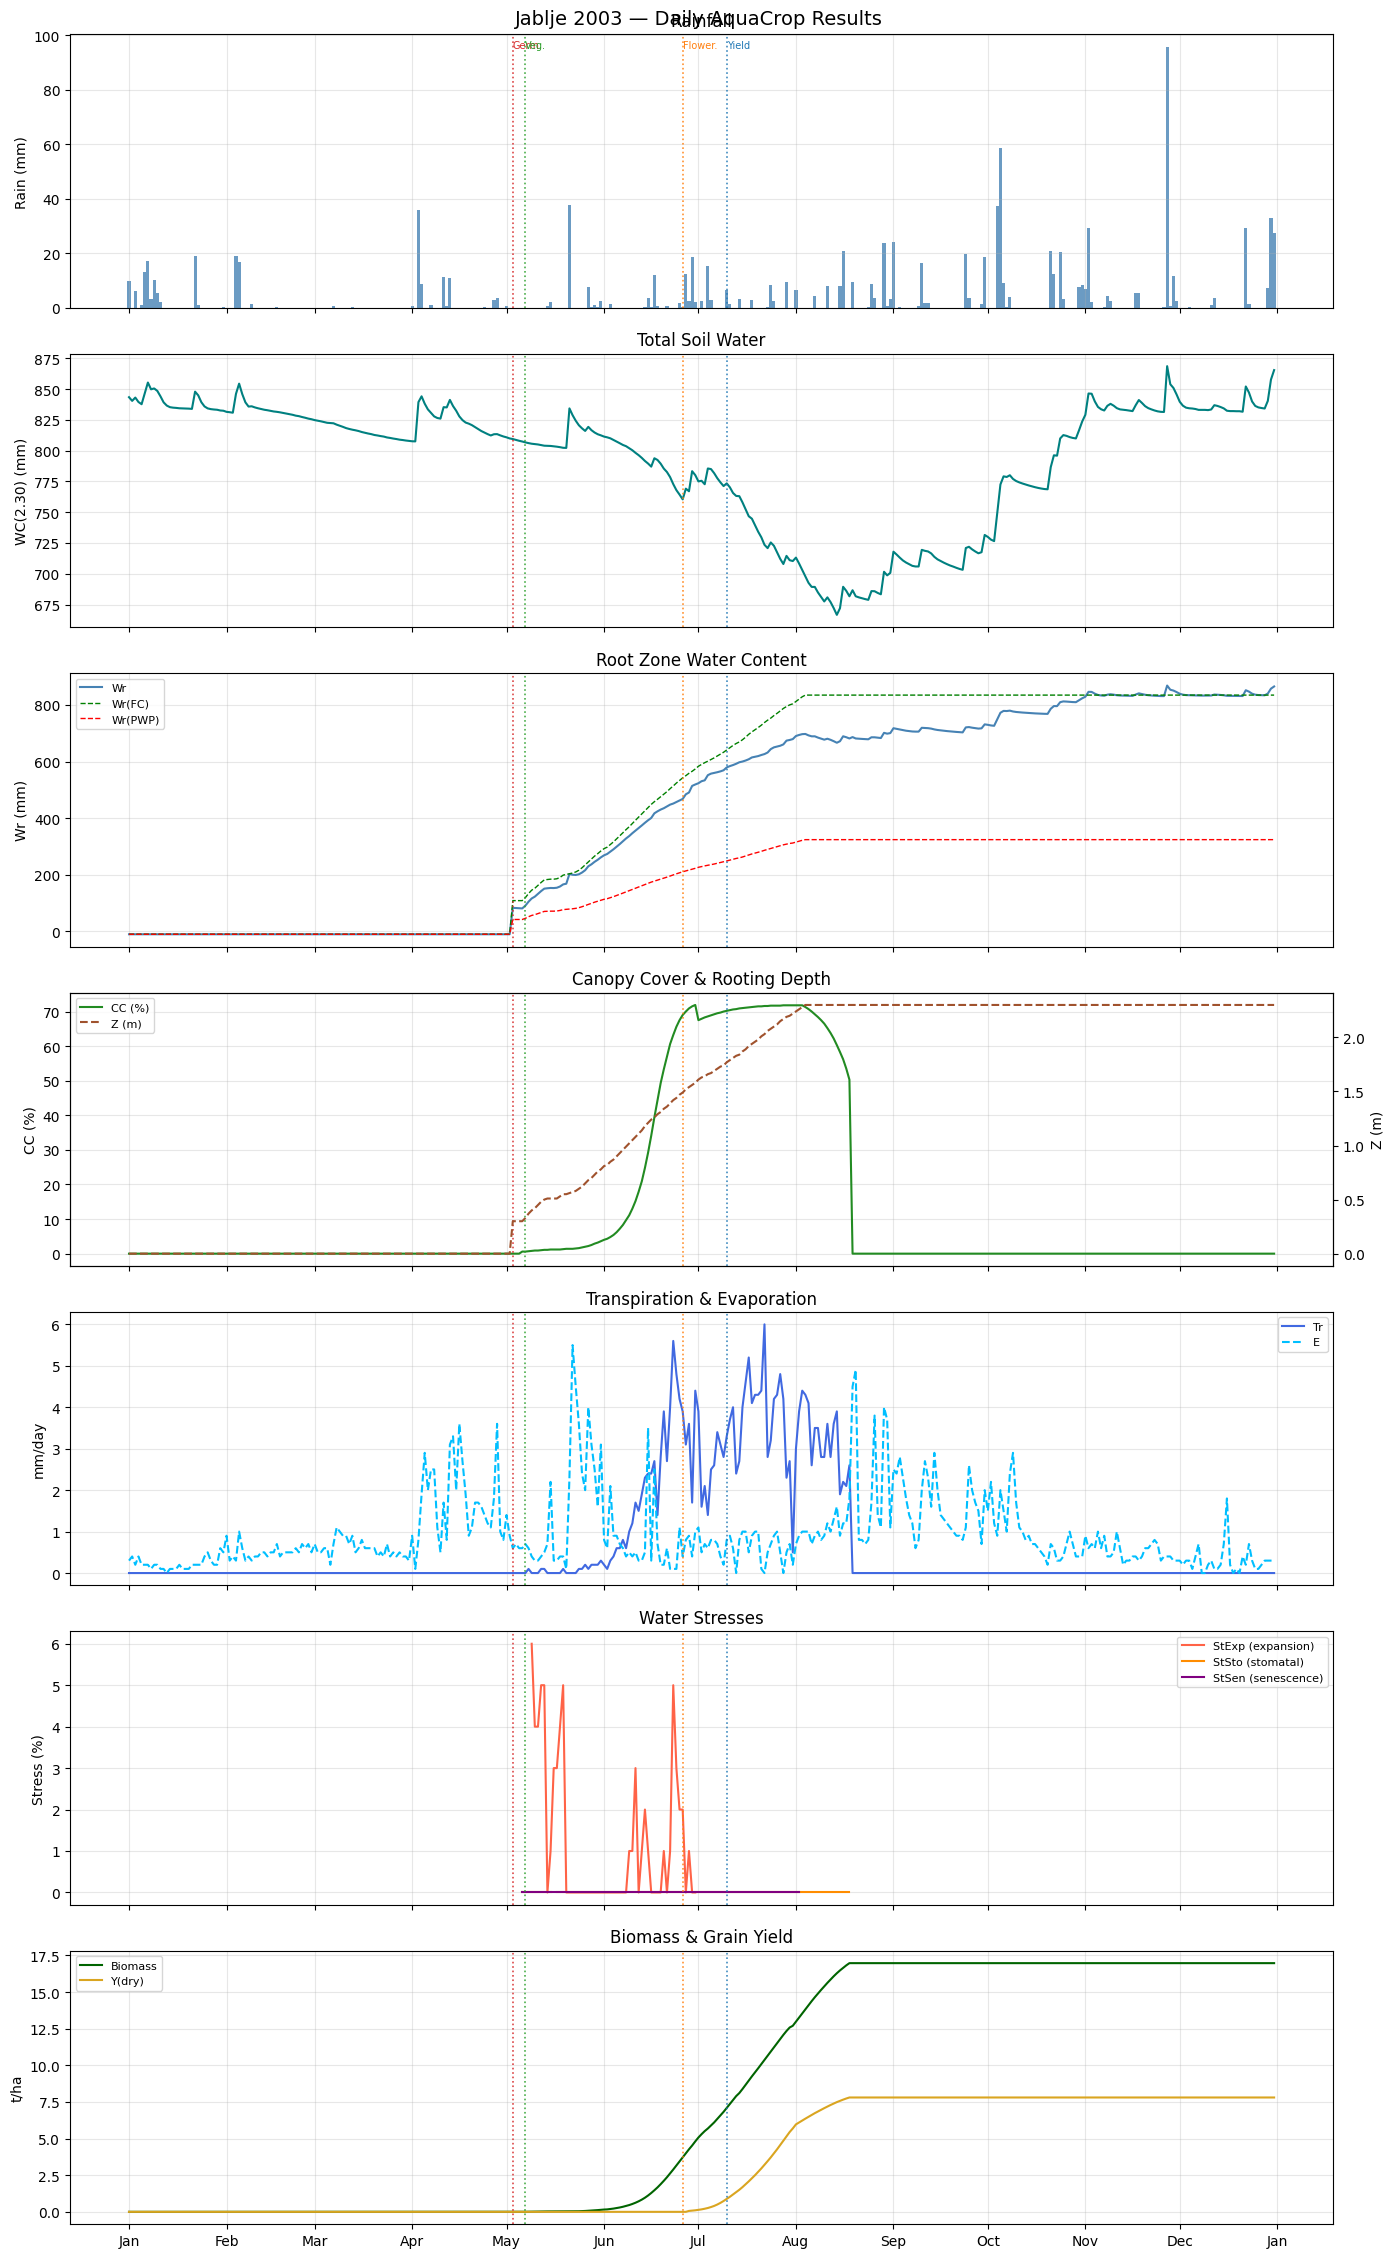

In [30]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd
from aquacrop.output import OutputReader as _DailyReader

_r = _DailyReader(output_dir=str(output_dir / "OUTP"))
_r.scan_directory()
day = _r.get_day_data(run_number=SPINUP_YEARS + 1)
day["date"] = pd.to_datetime(dict(year=day["Year"], month=day["Month"], day=day["Day"]))

def to_num(name):
    s = pd.to_numeric(day[name], errors="coerce")
    return s.where(s != -9)  # replace -9 sentinel (outside season) with NaN

wc_total_col = next(c for c in day.columns if c.startswith("WC("))

# Phenological stage transitions (first day each stage becomes active)
STAGE_LABELS = {1: "Germ.", 2: "Veg.", 3: "Flower.", 4: "Yield", 5: "Senes.", 6: "Mat."}
STAGE_COLORS = {1: "#d62728", 2: "#2ca02c", 3: "#ff7f0e", 4: "#1f77b4", 5: "#9467bd", 6: "#8c564b"}

stage_s = pd.to_numeric(day["Stage"], errors="coerce")
mask = (stage_s > 0) & (stage_s != stage_s.shift(1))
stage_transitions = day.loc[mask, ["date", "Stage"]].copy()
stage_transitions.loc[:, "Stage"] = stage_transitions["Stage"].astype(int)

fig, axes = plt.subplots(7, 1, figsize=(14, 23), sharex=True)
dates = day["date"]

# Rain
ax = axes[0]
ax.bar(dates, to_num("Rain"), color="steelblue", alpha=0.8, width=1)
ax.set_ylabel("Rain (mm)")
ax.set_title("Rainfall")

# Total soil water content
ax = axes[1]
ax.plot(dates, to_num(wc_total_col), color="teal")
ax.set_ylabel(f"{wc_total_col} (mm)")
ax.set_title("Total Soil Water")

# Root zone water content with FC and PWP thresholds
ax = axes[2]
ax.plot(dates, to_num("Wr"), color="steelblue", label="Wr")
ax.plot(dates, to_num("Wr(FC)"), color="green", linestyle="--", linewidth=1, label="Wr(FC)")
ax.plot(dates, to_num("Wr(PWP)"), color="red", linestyle="--", linewidth=1, label="Wr(PWP)")
ax.set_ylabel("Wr (mm)")
ax.legend(loc="upper left", fontsize=8)
ax.set_title("Root Zone Water Content")

# Canopy cover + rooting depth
ax = axes[3]
ax.plot(dates, to_num("CC"), color="forestgreen", label="CC (%)")
ax.set_ylabel("CC (%)")
ax2 = ax.twinx()
ax2.plot(dates, to_num("Z"), color="sienna", linestyle="--", label="Z (m)")
ax2.set_ylabel("Z (m)")
lines1, labs1 = ax.get_legend_handles_labels()
lines2, labs2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labs1 + labs2, loc="upper left", fontsize=8)
ax.set_title("Canopy Cover & Rooting Depth")

# Transpiration & evaporation
ax = axes[4]
ax.plot(dates, to_num("Tr"), color="royalblue", label="Tr")
ax.plot(dates, to_num("E"), color="deepskyblue", linestyle="--", label="E")
ax.set_ylabel("mm/day")
ax.legend(loc="upper right", fontsize=8)
ax.set_title("Transpiration & Evaporation")

# Water stresses (0 = none, 100 = full)
ax = axes[5]
ax.plot(dates, to_num("StExp"), color="tomato", label="StExp (expansion)")
ax.plot(dates, to_num("StSto"), color="darkorange", label="StSto (stomatal)")
ax.plot(dates, to_num("StSen"), color="purple", label="StSen (senescence)")
ax.set_ylabel("Stress (%)")
ax.legend(loc="upper right", fontsize=8)
ax.set_title("Water Stresses")

# Biomass & grain yield
ax = axes[6]
ax.plot(dates, to_num("Biomass"), color="darkgreen", label="Biomass")
ax.plot(dates, to_num("Y(dry)"), color="goldenrod", label="Y(dry)")
ax.set_ylabel("t/ha")
ax.legend(loc="upper left", fontsize=8)
ax.set_title("Biomass & Grain Yield")

for ax in axes:
    ax.xaxis_date()
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.grid(True, alpha=0.3)

# Stage lines through all panels; labels only on top panel
for _, row in stage_transitions.iterrows():
    s = row["Stage"]
    color = STAGE_COLORS.get(s, "gray")
    label = STAGE_LABELS.get(s, f"Stage {s}")
    for ax in axes:
        ax.axvline(row["date"], color=color, linestyle=":", linewidth=1.2, alpha=0.85)
    axes[0].text(
        row["date"], 0.98, label,
        transform=axes[0].get_xaxis_transform(),
        color=color, fontsize=7, ha="left", va="top",
    )

plt.suptitle(f"Jablje {year} — Daily AquaCrop Results", fontsize=14)
plt.tight_layout()
plt.show()

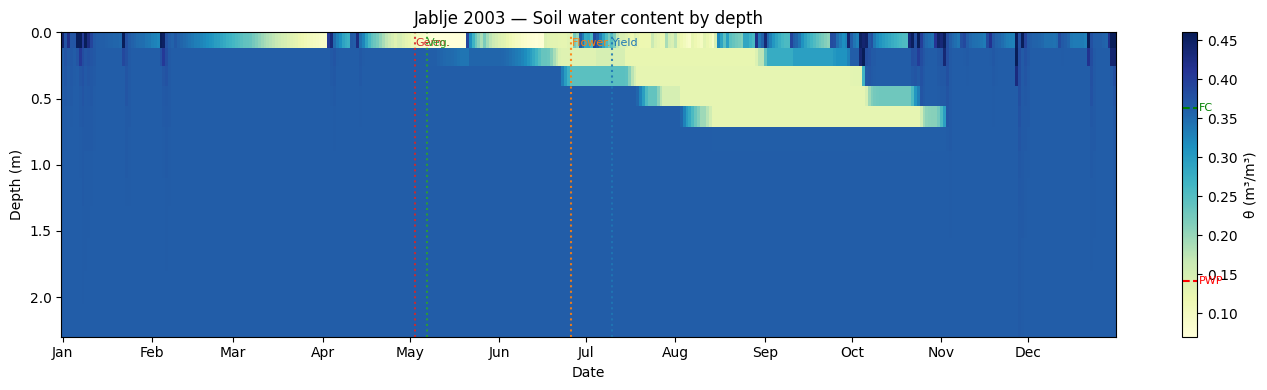

In [31]:
import pathlib
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.transforms as mtransforms
import numpy as np
import pandas as pd
from aquacrop.output import OutputReader
from aquacrop_slovenia.parameter_defaults_jablje import jablje_soil_layers

reader = OutputReader(output_dir=str(output_dir / "OUTP"))
reader.scan_directory()
all_days = reader.get_day_data(run_number=SPINUP_YEARS + 1)
all_days["date"] = pd.to_datetime(dict(year=all_days["Year"], month=all_days["Month"], day=all_days["Day"]))

# AquaCrop writes "WC 2"–"WC 9" with spaces. The parser splits each into two tokens ("WC" + number),
# producing 8 extra column name slots. Data positions 69-80 (the 12 WC values) therefore land in
# alternating WC_N and bare-number columns. "WC_6"–"WC12" end up in the ECe section (all zeros).
wc_cols = ["WC01", "WC", "2", "WC_1", "3", "WC_2", "4", "WC_3", "5", "WC_4", "6", "WC_5"]

# Read compartment depth centres from the output file units row (line 5) at runtime
day_file = next(pathlib.Path(output_dir / "OUTP").glob("*day.OUT"))
with open(day_file) as f:
    units_line = f.readlines()[4]
numeric_units = []
for x in units_line.split():
    try:
        numeric_units.append(float(x))
    except ValueError:
        pass
centers = np.array(numeric_units[:12])

wc_total_col = next(c for c in all_days.columns if c.startswith("WC("))
total_depth = float(wc_total_col[3:-1])
bounds = np.concatenate([[0.0], (centers[:-1] + centers[1:]) / 2, [total_depth]])

# WC values are in vol%; convert to volumetric water content θ [m³/m³]
wc    = all_days[wc_cols].values.astype(float)
theta = wc / 100

dates   = mdates.date2num(all_days["date"].values)
x_edges = np.concatenate([[dates[0] - 0.5], dates + 0.5])

fig, ax = plt.subplots(figsize=(14, 4))
im = ax.pcolormesh(x_edges, bounds, theta.T, cmap="YlGnBu", shading="flat")
ax.set_ylim(total_depth, 0)  # surface at top
ax.xaxis_date()
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.set_xlabel("Date")
ax.set_ylabel("Depth (m)")
ax.set_title(f"Jablje {year} — Soil water content by depth")

# Colorbar with FC and PWP markers
# Jablje has a single uniform soil layer; FC and PWP are the same at all depths.
theta_fc  = jablje_soil_layers[0].fc / 100   # vol% → m³/m³
theta_pwp = jablje_soil_layers[0].wp / 100

cb = plt.colorbar(im, ax=ax, label="θ (m³/m³)")
cb.ax.axhline(theta_fc,  color="green", linewidth=1.5, linestyle="--")
cb.ax.axhline(theta_pwp, color="red",   linewidth=1.5, linestyle="--")
trans = mtransforms.blended_transform_factory(cb.ax.transAxes, cb.ax.transData)
cb.ax.text(1.1, theta_fc,  "FC",  transform=trans, va="center", ha="left",
           fontsize=8, color="green", clip_on=False)
cb.ax.text(1.1, theta_pwp, "PWP", transform=trans, va="center", ha="left",
           fontsize=8, color="red",   clip_on=False)

# Phenological stage lines
STAGE_LABELS = {1: "Germ.", 2: "Veg.", 3: "Flower.", 4: "Yield", 5: "Senes.", 6: "Mat."}
STAGE_COLORS = {1: "#d62728", 2: "#2ca02c", 3: "#ff7f0e", 4: "#1f77b4", 5: "#9467bd", 6: "#8c564b"}

stage_s = pd.to_numeric(all_days["Stage"], errors="coerce")
mask = (stage_s > 0) & (stage_s != stage_s.shift(1))
transitions = all_days.loc[mask, ["date", "Stage"]].copy()
transitions.loc[:, "Stage"] = transitions["Stage"].astype(int)

for _, row in transitions.iterrows():
    s = row["Stage"]
    color = STAGE_COLORS.get(s, "gray")
    label = STAGE_LABELS.get(s, f"Stage {s}")
    ax.axvline(row["date"], color=color, linestyle=":", linewidth=1.5, alpha=0.9)
    ax.text(
        row["date"], 0.98, label,
        transform=ax.get_xaxis_transform(),
        color=color, fontsize=8, ha="left", va="top",
    )

plt.tight_layout()
plt.show()

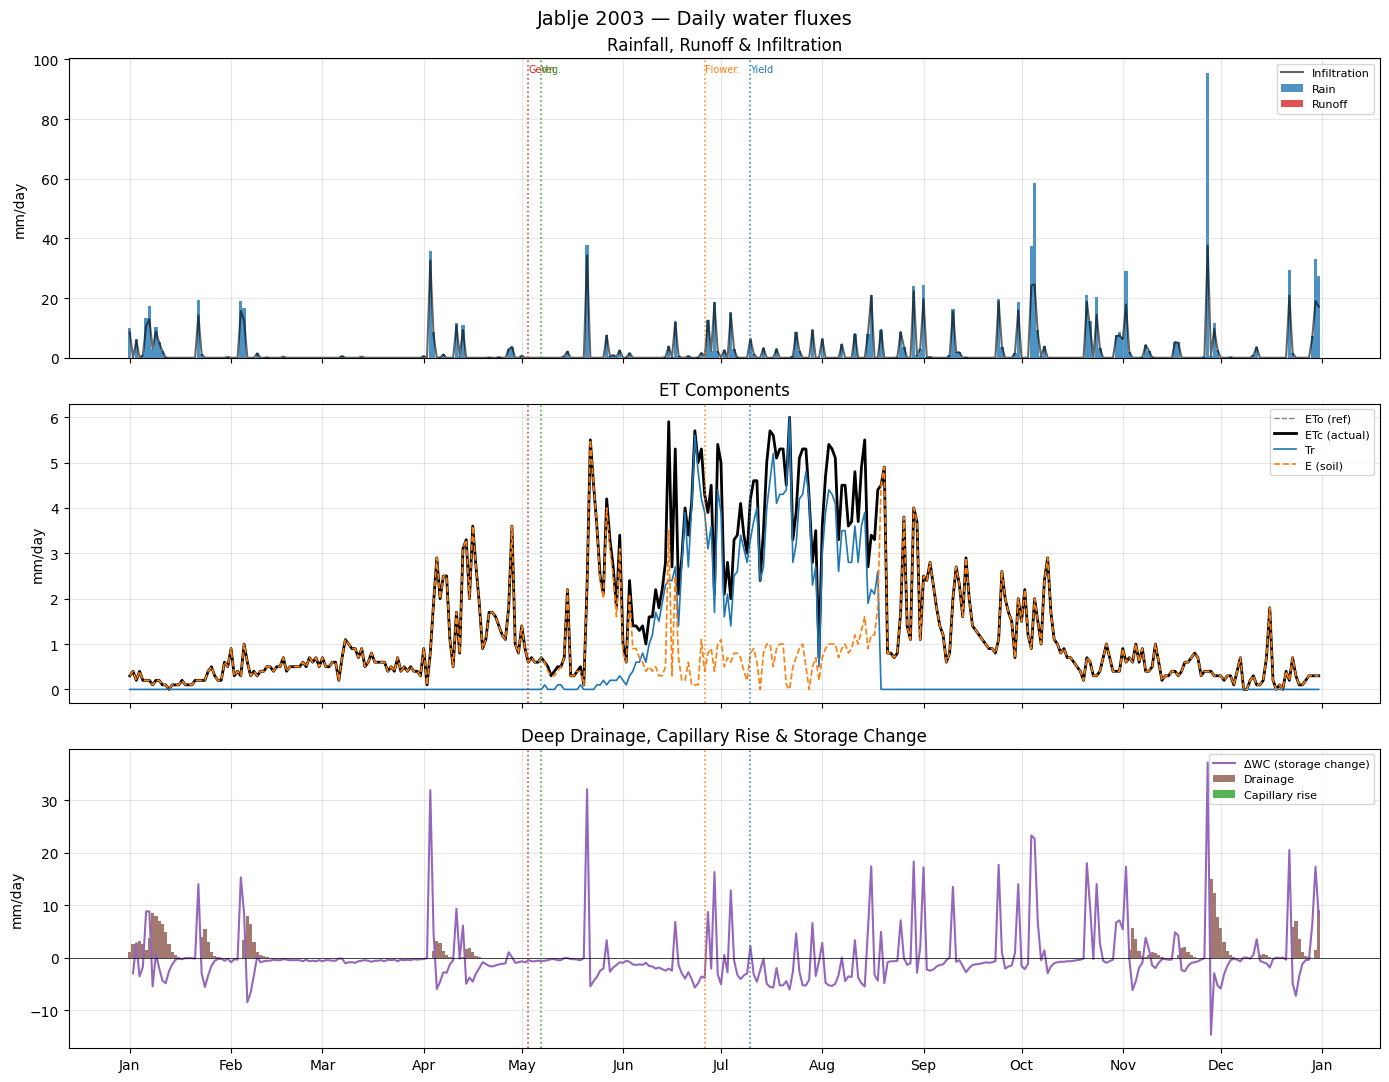

In [32]:
fig, axes = plt.subplots(3, 1, figsize=(14, 11), sharex=True)
fig.suptitle(f"Jablje {year} — Daily water fluxes", fontsize=14)

_dates = day["date"]

# Rainfall, runoff, infiltration
ax = axes[0]
ax.bar(_dates, to_num("Rain"),    color="#1f77b4", alpha=0.8, width=1, label="Rain")
ax.bar(_dates, to_num("Surf"),    color="#d62728", alpha=0.8, width=1, label="Runoff")
ax.plot(_dates, to_num("Infilt"), color="k", alpha=0.6, linewidth=1.5, label="Infiltration")
ax.set_ylabel("mm/day")
ax.legend(fontsize=8, loc="upper right")
ax.set_title("Rainfall, Runoff & Infiltration")

# ET components: actual vs potential
ax = axes[1]
ax.plot(_dates, to_num("ETo"), color="#7f7f7f", linestyle="--", linewidth=1,   label="ETo (ref)")
ax.plot(_dates, to_num("ET"),  color="#000000", linewidth=2,                   label="ETc (actual)")
ax.plot(_dates, to_num("Tr"),  color="#1f77b4", linewidth=1.2,                 label="Tr")
ax.plot(_dates, to_num("E"),   color="#ff7f0e", linestyle="--", linewidth=1.2, label="E (soil)")
ax.set_ylabel("mm/day")
ax.legend(fontsize=8, loc="upper right")
ax.set_title("ET Components")

# Deep drainage, capillary rise, storage change
ax = axes[2]
ax.bar(_dates, to_num("Drain"), color="#8c564b", alpha=0.8, width=1, label="Drainage")
ax.bar(_dates, to_num("CR"),    color="#2ca02c", alpha=0.8, width=1, label="Capillary rise")
ax.plot(_dates, pd.to_numeric(day[wc_total_col], errors="coerce").diff(),
        color="#9467bd", linewidth=1.5, label="ΔWC (storage change)")
ax.axhline(0, color="black", linewidth=0.5)
ax.set_ylabel("mm/day")
ax.legend(fontsize=8, loc="upper right")
ax.set_title("Deep Drainage, Capillary Rise & Storage Change")

for ax in axes:
    ax.xaxis_date()
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.grid(True, alpha=0.3)

for _, row in stage_transitions.iterrows():
    s = row["Stage"]
    color = STAGE_COLORS.get(s, "gray")
    label = STAGE_LABELS.get(s, f"Stage {s}")
    for ax in axes:
        ax.axvline(row["date"], color=color, linestyle=":", linewidth=1.2, alpha=0.85)
    axes[0].text(
        row["date"], 0.98, label,
        transform=axes[0].get_xaxis_transform(),
        color=color, fontsize=7, ha="left", va="top",
    )

plt.tight_layout()
plt.show()